##  generate pseudobulk from InSitu-Experiment

In [11]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# import packages
from insitupy import InSituData, ImageData, CACHE
from insitupy import InSituExperiment

from pathlib import Path

In [13]:
import anndata as ad
import pandas as pd
import scanpy as sc

In [14]:
exp = InSituExperiment.from_config(config_path="/Volumes/Daten/results/metadata_corrected.csv")

100%|██████████| 18/18 [00:00<00:00, 69.34it/s]


In [15]:
exp

InSituExperiment with 18 samples:
           uid  CITAR slide_id    sample_id patient_id     sample_type      tumor_area     mgmt_status
0     b697685d  -----  0017313    N-42-20-T          1  initial dia...   tumor-centrum      methylated
1     47833da5  -----  0017313   N-245-23-N          2       relapse 1  infiltratio...  not methylated
2     730ea6d1  -----  0017313   N-245-23-T          2       relapse 1   tumor-centrum  not methylated
3     12c8cb5f  -----  0017321   N-436-21-N          4  initial dia...  infiltratio...      methylated
4     52968806  -----  0017321   N-436-21-T          4  initial dia...   tumor-centrum      methylated
5     b59bc65a  -----  0017313   N-480-21-N          1       relapse 2  infiltratio...      methylated
6     be24d6e9  -----  0017313   N-480-21-T          1       relapse 2   tumor-centrum      methylated
7     40b11231  -----  0017321   N-851-22-N          4       relapse 1  infiltratio...      methylated
8     21173e71  -----  0017321   N-851-

In [16]:
for metadata,data in exp.iterdata():
    #data.load_all()
    data.load_cells()

In [17]:
exp

InSituExperiment with 18 samples:
           uid  CITAR slide_id    sample_id patient_id     sample_type      tumor_area     mgmt_status
0     b697685d  +----  0017313    N-42-20-T          1  initial dia...   tumor-centrum      methylated
1     47833da5  +----  0017313   N-245-23-N          2       relapse 1  infiltratio...  not methylated
2     730ea6d1  +----  0017313   N-245-23-T          2       relapse 1   tumor-centrum  not methylated
3     12c8cb5f  +----  0017321   N-436-21-N          4  initial dia...  infiltratio...      methylated
4     52968806  +----  0017321   N-436-21-T          4  initial dia...   tumor-centrum      methylated
5     b59bc65a  +----  0017313   N-480-21-N          1       relapse 2  infiltratio...      methylated
6     be24d6e9  +----  0017313   N-480-21-T          1       relapse 2   tumor-centrum      methylated
7     40b11231  +----  0017321   N-851-22-N          4       relapse 1  infiltratio...      methylated
8     21173e71  +----  0017321   N-851-

In [18]:
exp.data[0].cells['proseg'].matrix.obs['patient_id']='1'
exp.data[10].cells['proseg'].matrix.obs['patient_id']='1'
exp.data[9].cells['proseg'].matrix.obs['patient_id']='1'
exp.data[6].cells['proseg'].matrix.obs['patient_id']='1'
exp.data[5].cells['proseg'].matrix.obs['patient_id']='1'

exp.data[17].cells['proseg'].matrix.obs['patient_id']='2'
exp.data[16].cells['proseg'].matrix.obs['patient_id']='2'
exp.data[2].cells['proseg'].matrix.obs['patient_id']='2'
exp.data[1].cells['proseg'].matrix.obs['patient_id']='2'

exp.data[13].cells['proseg'].matrix.obs['patient_id']='3'
exp.data[12].cells['proseg'].matrix.obs['patient_id']='3'
exp.data[11].cells['proseg'].matrix.obs['patient_id']='3'
exp.data[15].cells['proseg'].matrix.obs['patient_id']='3'
exp.data[14].cells['proseg'].matrix.obs['patient_id']='3'

exp.data[4].cells['proseg'].matrix.obs['patient_id']='4'
exp.data[3].cells['proseg'].matrix.obs['patient_id']='4'
exp.data[8].cells['proseg'].matrix.obs['patient_id']='4'
exp.data[7].cells['proseg'].matrix.obs['patient_id']='4'

In [19]:
# sample type
exp.data[0].cells['proseg'].matrix.obs['sample_type']='initial diagnosis'
exp.data[17].cells['proseg'].matrix.obs['sample_type']='initial diagnosis'
exp.data[16].cells['proseg'].matrix.obs['sample_type']='initial diagnosis'
exp.data[13].cells['proseg'].matrix.obs['sample_type']='initial diagnosis'
exp.data[4].cells['proseg'].matrix.obs['sample_type']='initial diagnosis'
exp.data[3].cells['proseg'].matrix.obs['sample_type']='initial diagnosis'

exp.data[10].cells['proseg'].matrix.obs['sample_type']='relapse 1'
exp.data[9].cells['proseg'].matrix.obs['sample_type']='relapse 1'
exp.data[2].cells['proseg'].matrix.obs['sample_type']='relapse 1'
exp.data[1].cells['proseg'].matrix.obs['sample_type']='relapse 1'
exp.data[12].cells['proseg'].matrix.obs['sample_type']='relapse 1'
exp.data[11].cells['proseg'].matrix.obs['sample_type']='relapse 1'
exp.data[8].cells['proseg'].matrix.obs['sample_type']='relapse 1'
exp.data[7].cells['proseg'].matrix.obs['sample_type']='relapse 1'

exp.data[6].cells['proseg'].matrix.obs['sample_type']='relapse 2'
exp.data[5].cells['proseg'].matrix.obs['sample_type']='relapse 2'
exp.data[15].cells['proseg'].matrix.obs['sample_type']='relapse 2'
exp.data[14].cells['proseg'].matrix.obs['sample_type']='relapse 2'

In [20]:
# tumor area
exp.data[0].cells['proseg'].matrix.obs['tumor_area']='tumor center'
exp.data[10].cells['proseg'].matrix.obs['tumor_area']='tumor center'
exp.data[6].cells['proseg'].matrix.obs['tumor_area']='tumor center'
exp.data[17].cells['proseg'].matrix.obs['tumor_area']='tumor center'
exp.data[2].cells['proseg'].matrix.obs['tumor_area']='tumor center'
exp.data[13].cells['proseg'].matrix.obs['tumor_area']='tumor center'
exp.data[12].cells['proseg'].matrix.obs['tumor_area']='tumor center'
exp.data[15].cells['proseg'].matrix.obs['tumor_area']='tumor center'
exp.data[4].cells['proseg'].matrix.obs['tumor_area']='tumor center'
exp.data[8].cells['proseg'].matrix.obs['tumor_area']='tumor center'


exp.data[9].cells['proseg'].matrix.obs['tumor_area']='infiltrationzone'
exp.data[5].cells['proseg'].matrix.obs['tumor_area']='infiltrationzone'
exp.data[16].cells['proseg'].matrix.obs['tumor_area']='infiltrationzone'
exp.data[1].cells['proseg'].matrix.obs['tumor_area']='infiltrationzone'
exp.data[11].cells['proseg'].matrix.obs['tumor_area']='infiltrationzone'
exp.data[14].cells['proseg'].matrix.obs['tumor_area']='infiltrationzone'
exp.data[3].cells['proseg'].matrix.obs['tumor_area']='infiltrationzone'
exp.data[7].cells['proseg'].matrix.obs['tumor_area']='infiltrationzone'

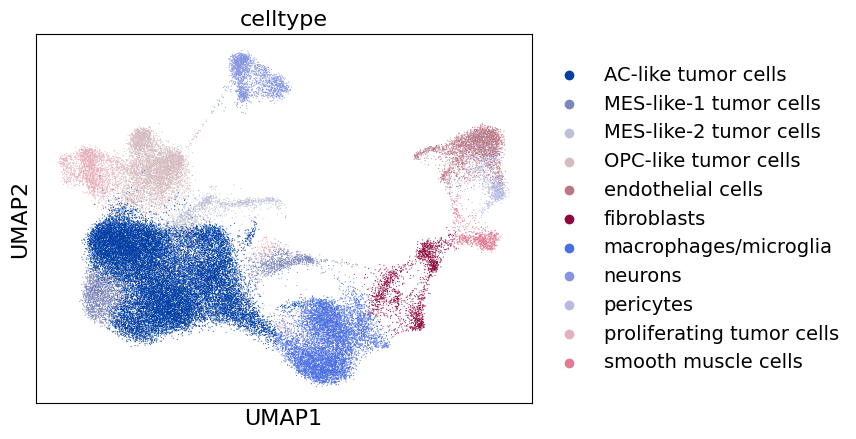

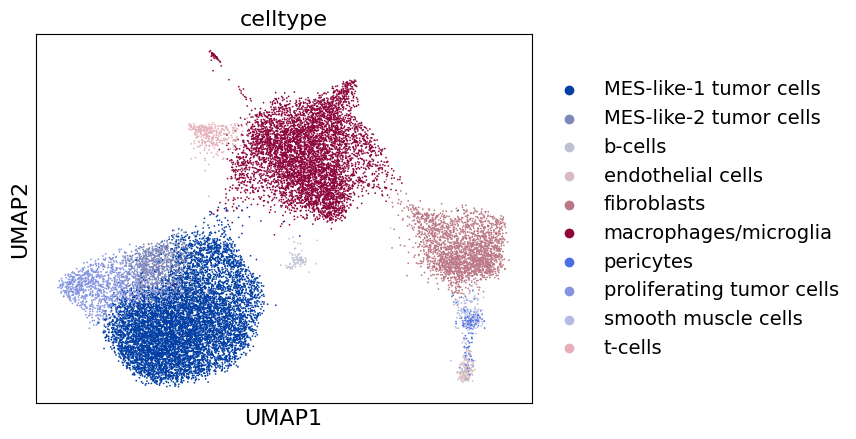

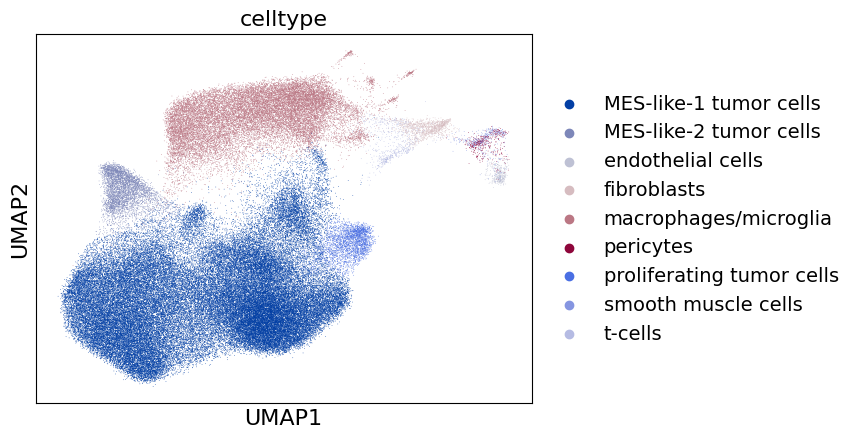

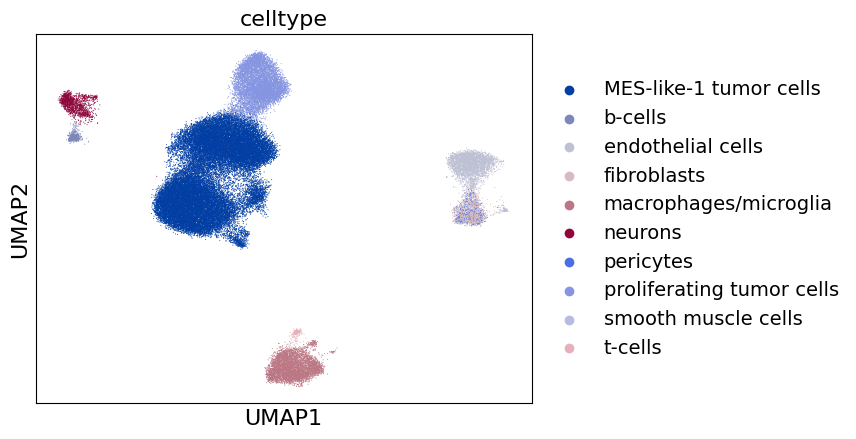

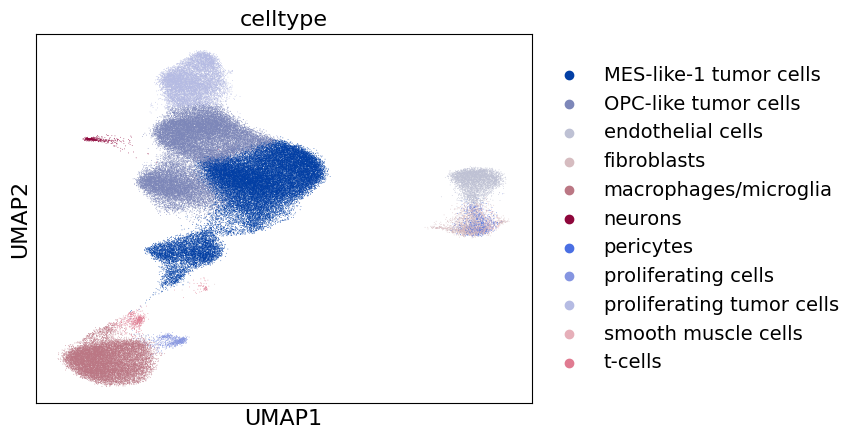

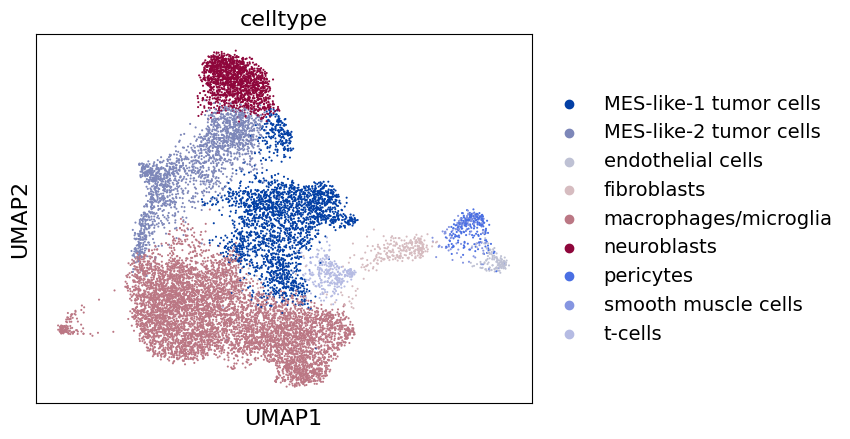

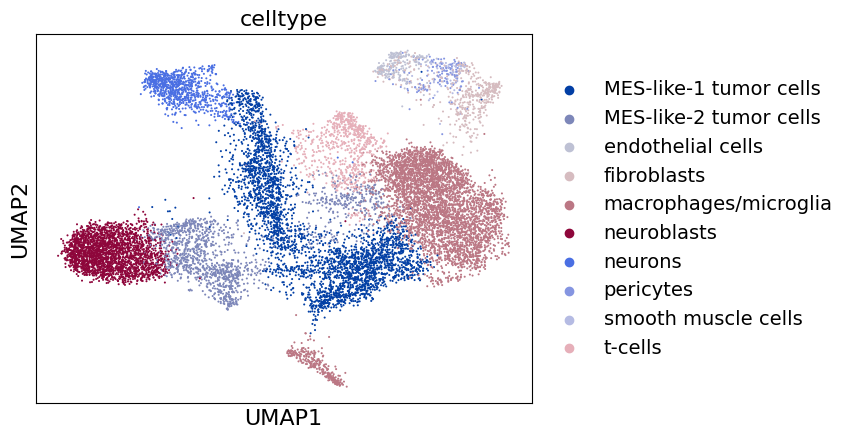

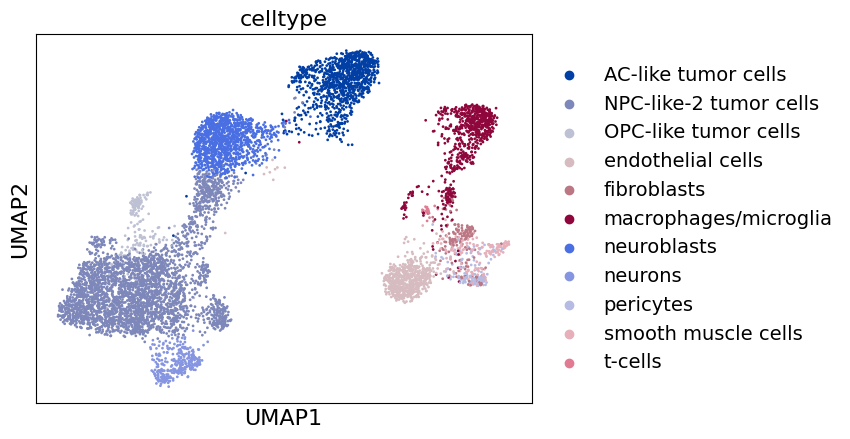

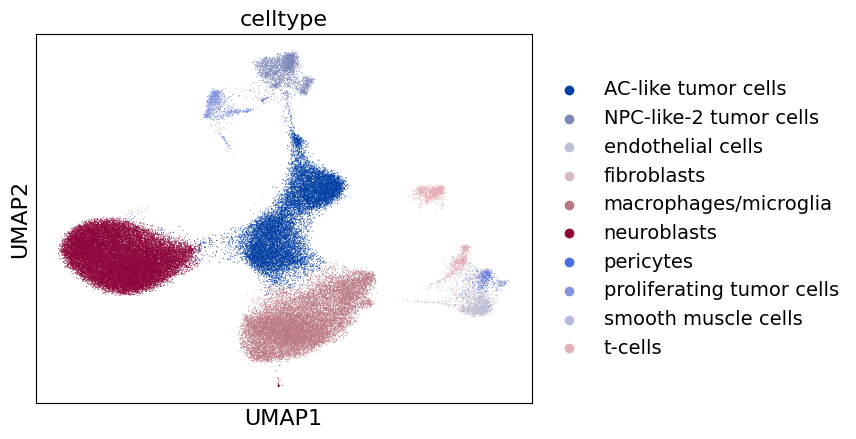

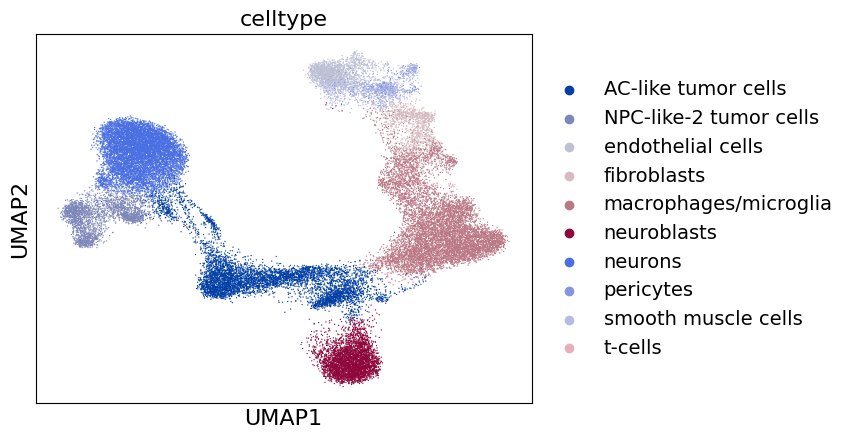

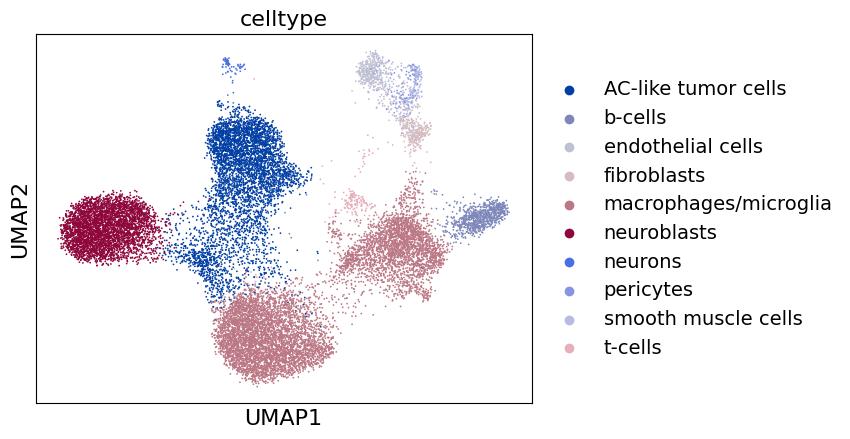

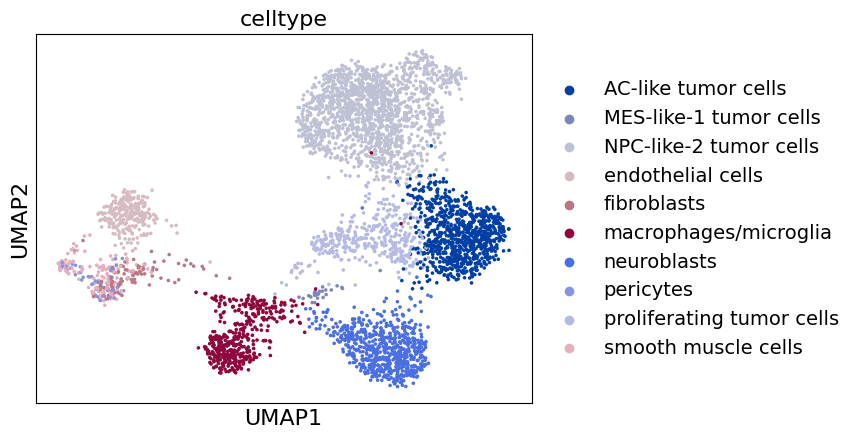

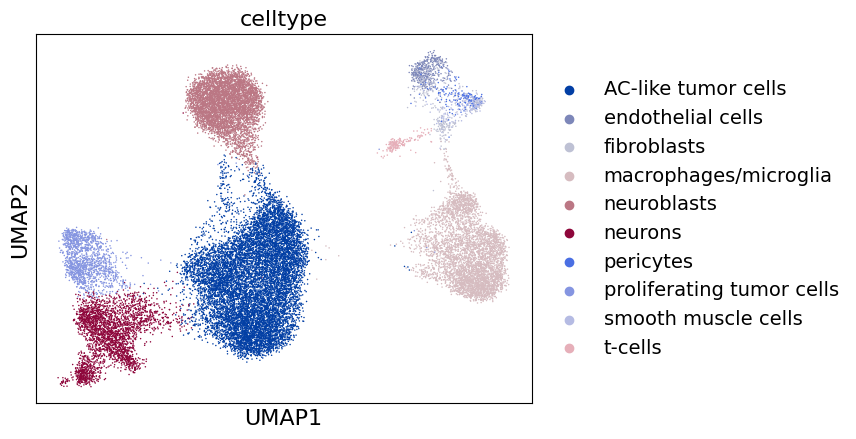

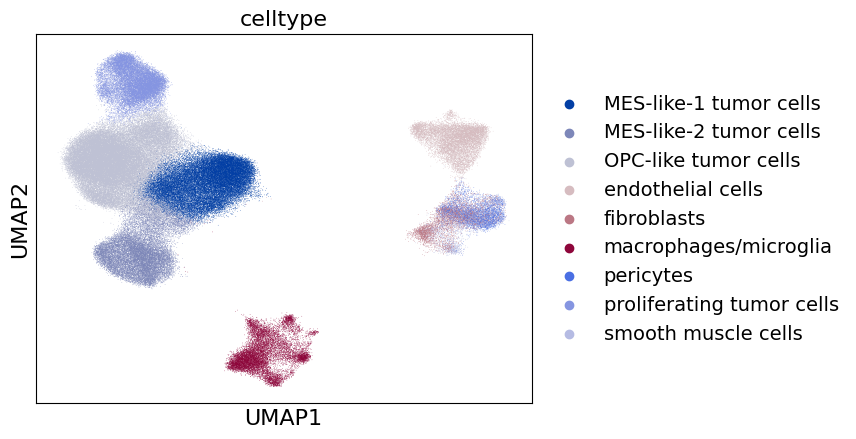

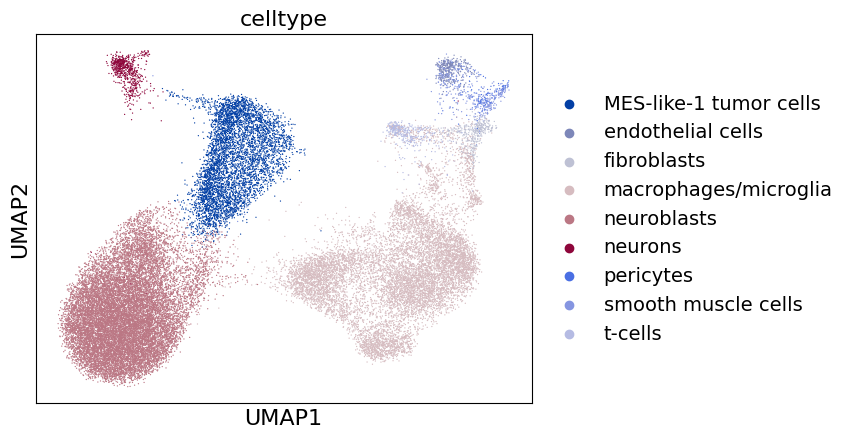

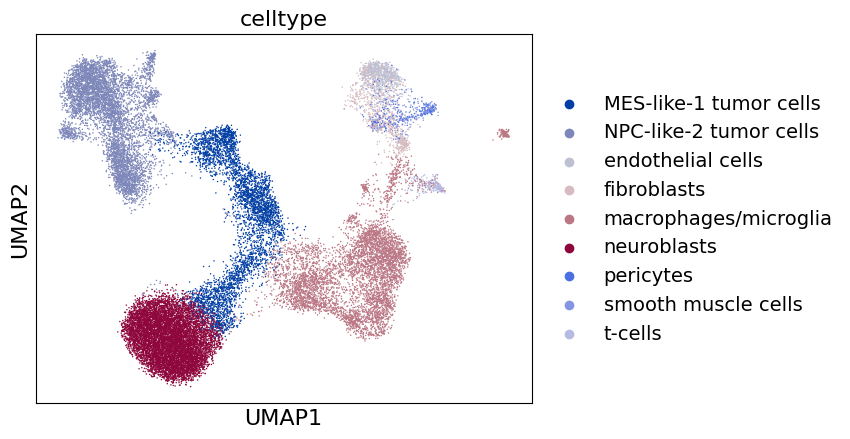

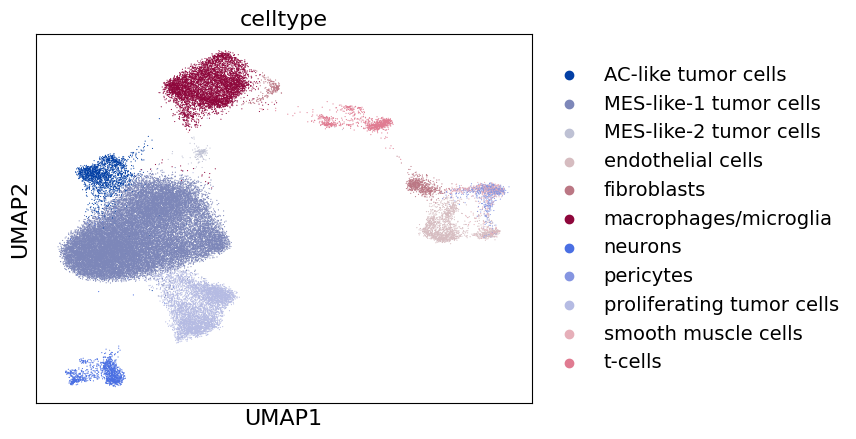

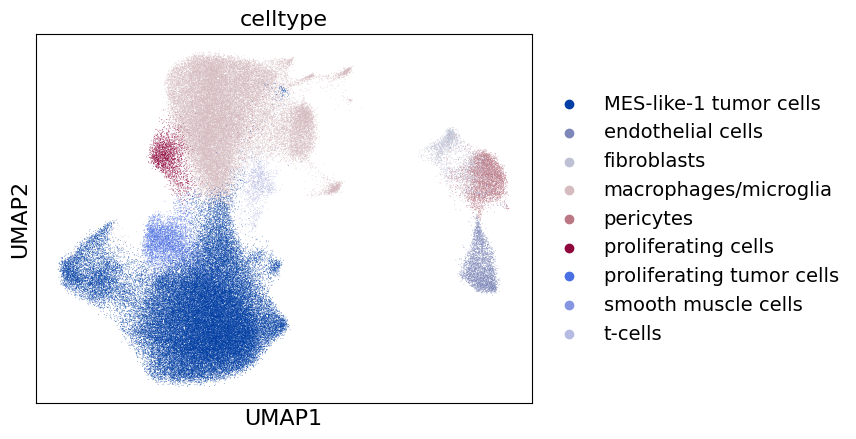

In [21]:
for metadata, data in exp.iterdata():
    sc.pl.umap(data.cells['proseg'].matrix,color=['celltype'])

In [22]:
exp

InSituExperiment with 18 samples:
           uid  CITAR slide_id    sample_id patient_id     sample_type      tumor_area     mgmt_status
0     b697685d  +----  0017313    N-42-20-T          1  initial dia...   tumor-centrum      methylated
1     47833da5  +----  0017313   N-245-23-N          2       relapse 1  infiltratio...  not methylated
2     730ea6d1  +----  0017313   N-245-23-T          2       relapse 1   tumor-centrum  not methylated
3     12c8cb5f  +----  0017321   N-436-21-N          4  initial dia...  infiltratio...      methylated
4     52968806  +----  0017321   N-436-21-T          4  initial dia...   tumor-centrum      methylated
5     b59bc65a  +----  0017313   N-480-21-N          1       relapse 2  infiltratio...      methylated
6     be24d6e9  +----  0017313   N-480-21-T          1       relapse 2   tumor-centrum      methylated
7     40b11231  +----  0017321   N-851-22-N          4       relapse 1  infiltratio...      methylated
8     21173e71  +----  0017321   N-851-

In [81]:
import numpy as np
import anndata

In [82]:
from anndata import AnnData

In [25]:
from scipy.sparse import csr_matrix, issparse

In [26]:
from anndata.experimental import AnnCollection


In [27]:
import matplotlib.pyplot as plt

In [28]:
import seaborn as sns

In [83]:
import sys
sys.path.append('/Users/birthi/InSituPy-1/InSituPy/insitupy/pseudobulk')

import std
from std import  tqdm

In [30]:
def psbulk_profile(profile, mode='sum'):
    if mode == 'sum':
        profile = np.sum(profile, axis=0)
    elif mode == 'mean':
        profile = np.mean(profile, axis=0)
    elif mode == 'median':
        profile = np.median(profile, axis=0)
    elif callable(mode):
        profile = np.apply_along_axis(mode, 0, profile)
    else:
        raise ValueError("""mode={0} can be 'sum', 'mean', 'median' or a callable function.""".format(mode))
    return profile

In [31]:
from scipy.sparse import vstack

In [32]:
def extract_psbulk_inputs(exp,layer='counts'):
    
    obs_columns_list = []
    for metadata, data in exp.iterdata():
        obs_columns_list.append(set(data.cells['proseg'].matrix.obs.columns))

    common_obs_columns = sorted(set.intersection(*obs_columns_list))
       
    obs = pd.DataFrame()
         
    for i in common_obs_columns:
        column_dict={}
        for metadata, data in exp.iterdata():
            column_dict[data.sample_id] = data.cells['proseg'].matrix.obs[i].copy()
                
        column=pd.concat([s.reset_index(drop=True) for s in column_dict.values()], axis=0)   
        obs[i]=column
                    
    var_names = []
    for metadata, data in exp.iterdata():
        var_names.append(set(data.cells['proseg'].matrix.var_names))

    common_var_names = sorted(set.intersection(*var_names))
    
    var = pd.DataFrame({"genes": common_var_names})

        # Extract count matrix X
    X_list=[]
    for metadata, data in exp.iterdata():
            ad = data.cells['proseg'].matrix
            ad = ad[:, ad.var_names.isin(common_var_names)]
            if layer is not None:
                X_list.append(ad.layers[layer])
            else:
                X_list.append(ad.X)
    X = vstack(X_list)
    
    # Sort genes
    msk = np.argsort(var["genes"])

    X = X[:, msk]
    var = var.iloc[msk]
    var.set_index('genes', inplace=True)

    if issparse(X) and not isinstance(X, csr_matrix):
        X = csr_matrix(X)

    return X, obs, var

In [33]:
def format_psbulk_inputs(sample_col, groups_col, obs):
    # Use one column if the same
    if sample_col == groups_col:
        groups_col = None

    if groups_col is None:
        # Filter extra columns in obs
        cols = obs.groupby(sample_col, observed=True).nunique(dropna=False).eq(1).all(0)
        cols = np.hstack([sample_col, cols[cols].index])
        obs = obs.loc[:, cols]

        # Get unique samples
        smples = np.unique(obs[sample_col].values)
        groups = None

        # Get number of samples and features
        n_rows = len(smples)
    else:
        # Check if extra grouping is needed
        if type(groups_col) is list:
            obs = obs.copy()
            joined_cols = '_'.join(groups_col)
            obs[joined_cols] = obs[groups_col[0]].str.cat(obs[groups_col[1:]].astype('U'), sep='_')
            groups_col = joined_cols

        # Filter extra columns in obs
        cols = obs.groupby([sample_col, groups_col], observed=True).nunique(dropna=False).eq(1).all(0)
        cols = np.hstack([sample_col, groups_col, cols[cols].index])
        obs = obs.loc[:, cols]

        # Get unique samples and groups
        smples = np.unique(obs[sample_col].values)
        groups = np.unique(obs[groups_col].values)

        # Get number of samples and features
        n_rows = len(smples) * len(groups)

    return obs, groups_col, smples, groups, n_rows

In [34]:
def psbulk_profile(profile, mode='sum'):
    if mode == 'sum':
        profile = np.sum(profile, axis=0)
    elif mode == 'mean':
        profile = np.mean(profile, axis=0)
    elif mode == 'median':
        profile = np.median(profile, axis=0)
    elif callable(mode):
        profile = np.apply_along_axis(mode, 0, profile)
    else:
        raise ValueError("""mode={0} can be 'sum', 'mean', 'median' or a callable function.""".format(mode))
    return profile

In [35]:
def compute_psbulk(n_rows, n_cols, X, sample_col, groups_col, smples, groups, obs,
                   new_obs, min_cells, min_counts, mode, dtype):

    # Init empty variables
    psbulk = np.zeros((n_rows, n_cols))
    props = np.zeros((n_rows, n_cols))
    ncells = np.zeros(n_rows)
    counts = np.zeros(n_rows)

    # Iterate for each group and sample
    i = 0
    if groups_col is None:
        for smp in smples:
            # Write new meta-data
            tmp = obs[obs[sample_col] == smp].drop_duplicates().values
            new_obs.loc[smp, :] = tmp

            # Get cells from specific sample
            profile = X[(obs[sample_col] == smp).values]
            if isinstance(X, csr_matrix):
                profile = profile.toarray()

            # Skip if few cells or not enough counts
            ncell = profile.shape[0]
            count = np.sum(profile)
            ncells[i] = ncell
            counts[i] = count
            if ncell < min_cells or np.abs(count) < min_counts:
                i += 1
                continue

            # Get prop of non zeros
            prop = np.sum(profile != 0, axis=0) / profile.shape[0]

            # Pseudo-bulk
            profile = psbulk_profile(profile, mode=mode)

            # Append
            props[i] = prop
            psbulk[i] = profile
            i += 1
    else:
        for grp in groups:
            for smp in smples:

                # Write new meta-data
                index = smp + '_' + grp
                tmp = obs[(obs[sample_col] == smp) & (obs[groups_col] == grp)].drop_duplicates().values
                if tmp.shape[0] == 0:
                    tmp = np.full(tmp.shape[1], np.nan)
                new_obs.loc[index, :] = tmp

                # Get cells from specific sample and group
                profile = X[((obs[sample_col] == smp) & (obs[groups_col] == grp)).values]
                if isinstance(X, csr_matrix):
                    profile = profile.toarray()

                # Skip if few cells or not enough counts
                ncell = profile.shape[0]
                count = np.sum(profile)
                ncells[i] = ncell
                counts[i] = count
                if ncell < min_cells or np.abs(count) < min_counts:
                    i += 1
                    continue

                # Get prop of non zeros
                prop = np.sum(profile != 0, axis=0) / profile.shape[0]

                # Pseudo-bulk
                profile = psbulk_profile(profile, mode=mode)

                # Append
                props[i] = prop
                psbulk[i] = profile
                i += 1

    return psbulk, ncells, counts, props


In [36]:
def filter_by_prop(adata, min_prop=0.2, min_smpls=2):
    """
    Determine which genes are expressed in a sufficient proportion of cells across samples.

    This function selects genes that are sufficiently expressed across cells in each sample and that this condition is
    met across a minimum number of samples.

    Parameters
    ----------
    adata : AnnData
        AnnData obtained after running ``decoupler.get_pseudobulk``. It requires ``.layer['psbulk_props']``.
    min_prop : float
        Minimum proportion of cells that express a gene in a sample.
    min_smpls : int
        Minimum number of samples with bigger or equal proportion of cells with expression than ``min_prop``.

    Returns
    -------
    genes : ndarray
        List of genes to be kept.
    """

    # Define limits
    min_prop = np.clip(min_prop, 0, 1)
    min_smpls = np.clip(min_smpls, 0, adata.shape[0])

    if isinstance(adata, AnnData):
        layer_keys = adata.layers.keys()
        if 'psbulk_props' in list(layer_keys):
            var_names = adata.var_names.values.astype('U')
            props = adata.layers['psbulk_props']
            if isinstance(props, pd.DataFrame):
                props = props.values

            # Compute n_smpl
            nsmpls = np.sum(props >= min_prop, axis=0)

            # Set features to 0
            msk = nsmpls >= min_smpls
            genes = var_names[msk]
            return genes
    raise ValueError("""adata must be an AnnData object that contains the layer 'psbulk_props'. Please check the function
                     decoupler.get_pseudobulk.""")


In [37]:
def swap_layer(adata, layer_key, X_layer_key='X', inplace=False):
    """
    Swaps an ``adata.X`` for a given layer.

    Swaps an AnnData ``X`` matrix with a given layer. Generates a new object by default.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix.
    layer_key : str
        ``.layers`` key to place in ``.X``.
    X_layer_key : str, None
        ``.layers`` key where to move and store the original ``.X``. If None, the original ``.X`` is discarded.
    inplace : bool
        If ``False``, return a copy. Otherwise, do operation inplace and return ``None``.

    Returns
    -------
    layer : AnnData, None
        If ``inplace=False``, new AnnData object.
    """

    cdata = None
    if inplace:
        if X_layer_key is not None:
            adata.layers[X_layer_key] = adata.X
        adata.X = adata.layers[layer_key]
    else:
        cdata = adata.copy()
        if X_layer_key is not None:
            cdata.layers[X_layer_key] = cdata.X
        cdata.X = cdata.layers[layer_key]

    return cdata

In [38]:
def check_X(X, mode='sum', skip_checks=False):
    if isinstance(X, csr_matrix):
        is_finite = np.all(np.isfinite(X.data))
    else:
        is_finite = np.all(np.isfinite(X))
    if not is_finite:
        raise ValueError('Data contains non finite values (nan or inf), please set them to 0 or remove them.')
    skip_checks = type(mode) is dict or callable(mode) or skip_checks
    if not skip_checks:
        if isinstance(X, csr_matrix):
            is_positive = np.all(X.data >= 0)
        else:
            is_positive = np.all(X >= 0)
        if not is_positive:
            raise ValueError("""Data contains negative values. Check the parameters use_raw and layers to
            determine if you are selecting the correct matrix. To override this, set skip_checks=True.
            """)
        if mode == 'sum':
            if isinstance(X, csr_matrix):
                is_integer = float(np.sum(X.data)).is_integer()
            else:
                is_integer = float(np.sum(X)).is_integer()
            if not is_integer:
                raise ValueError("""Data contains float (decimal) values. Check the parameters use_raw and layers to
                determine if you are selecting the correct data, which should be positive integer counts when mode='sum'.
                To override this, set skip_checks=True.
                """)

In [39]:
def get_pseudobulk(exp, sample_col=str, groups_col=str, obs=None, layer=str, use_raw=False, mode='sum', min_cells=10,
                   min_counts=1000, dtype=np.float32, skip_checks=False, min_prop=None, min_smpls=None, remove_empty=True):
    
    min_cells, min_counts = np.clip(min_cells, 1, None), np.clip(min_counts, 1, None)  

    X, obs, var = extract_psbulk_inputs(exp,layer)

    check_X(X, mode=mode, skip_checks=skip_checks)

    obs, groups_col, smples, groups, n_rows = format_psbulk_inputs(sample_col, groups_col, obs)
    n_cols = X.shape[1]
    new_obs = pd.DataFrame(columns=obs.columns)
    
    if type(mode) is dict:
        psbulks = []
        for l_name in mode:
            func = mode[l_name]
            if not callable(func):
                raise ValueError("""mode requieres a dictionary of layer names and callable functions. The layer {0} does not
                contain one.""".format(l_name))
            else:
                # Compute psbulk
                psbulk, ncells, counts, props = compute_psbulk(n_rows, n_cols, X, sample_col, groups_col, smples, groups, obs,
                                                               new_obs, min_cells, min_counts, func, dtype)
                psbulks.append(psbulk)
        layers = {k: v for k, v in zip(mode.keys(), psbulks)}
        layers['psbulk_props'] = props
    elif type(mode) is str or callable(mode):
        # Compute psbulk
        psbulk, ncells, counts, props = compute_psbulk(n_rows, n_cols, X, sample_col, groups_col, smples, groups, obs,
                                                       new_obs, min_cells, min_counts, mode, dtype)
        layers = {'psbulk_props': props}

    # Add QC metrics
    new_obs['psbulk_n_cells'] = ncells
    new_obs['psbulk_counts'] = counts

    # Create new AnnData
    psbulk = AnnData(psbulk.astype(dtype), obs=new_obs, var=var, layers=layers)

    # Remove empty samples and features
    if remove_empty:
        msk = psbulk.X == 0
        psbulk = psbulk[~np.all(msk, axis=1), ~np.all(msk, axis=0)].copy()

    # Place first element of mode dict as X
    if type(mode) is dict:
        swap_layer(psbulk, layer_key=list(mode.keys())[0], X_layer_key=None, inplace=True)

    # Filter by genes if not None.
    if min_prop is not None and min_smpls is not None:
        if groups_col is None:
            genes = filter_by_prop(psbulk, min_prop=min_prop, min_smpls=min_smpls)
        else:
            genes = []
            for group in groups:
                g = filter_by_prop(psbulk[psbulk.obs[groups_col] == group], min_prop=min_prop, min_smpls=min_smpls)
                genes.extend(g)
            genes = np.unique(genes)
        psbulk = psbulk[:, genes]

    return psbulk
    
    
        

    

In [40]:
psbulk=get_pseudobulk(exp, sample_col='batch', groups_col='celltype', obs=None, layer='counts', use_raw=False, mode='sum', min_cells=10,
                      min_counts=1000, dtype=np.float32, skip_checks=False, min_prop=None, min_smpls=None, remove_empty=True)

In [41]:
psbulk.obs

,batch,celltype,patient_id,sample_type,scale,tumor_area,psbulk_n_cells,psbulk_counts
N-1055-20-N_AC-like tumor cells,N-1055-20-N,AC-like tumor cells,1,relapse 1,1.0,infiltrationzone,6323.0,1087391.0
N-1055-20-T_AC-like tumor cells,N-1055-20-T,AC-like tumor cells,1,relapse 1,1.0,tumor center,4750.0,711652.0
N-1445-19-N_AC-like tumor cells,N-1445-19-N,AC-like tumor cells,3,relapse 1,1.0,infiltrationzone,850.0,88496.0
N-1445-19-T_AC-like tumor cells,N-1445-19-T,AC-like tumor cells,3,relapse 1,1.0,tumor center,11189.0,1578273.0
N-42-20-T_AC-like tumor cells,N-42-20-T,AC-like tumor cells,1,initial diagnosis,1.0,tumor center,24784.0,4595589.0
...,...,...,...,...,...,...,...,...
N-480-21-T_t-cells,N-480-21-T,t-cells,1,relapse 2,1.0,tumor center,694.0,120512.0
N-486-22-N_t-cells,N-486-22-N,t-cells,2,initial diagnosis,1.0,infiltrationzone,883.0,82994.0
N-486-22-T_t-cells,N-486-22-T,t-cells,2,initial diagnosis,1.0,tumor center,1274.0,256379.0
N-851-22-N_t-cells,N-851-22-N,t-cells,4,relapse 1,1.0,infiltrationzone,18.0,1557.0


In [42]:
psbulk.var

""
genes
A2ML1
ABCC9
ABCD4
ABO
ACKR1
...
XRCC1
XRCC3
XRCC5


In [43]:
def plot_psbulk_samples(adata, groupby, figsize=(5, 5), dpi=100, ax=None, return_fig=False, save=None, **kwargs):
    """
    Quality Control plot to assess the quality of the obtained pseudobulk samples.

    Parameters
    ----------
    adata : AnnData
        AnnData obtained after running ``decoupler.get_pseudobulk``.
    groupby : str, list
        Name of the ``.obs`` column to group by. Can also be a list of columns.
    figsize : tuple
        Figure size.
    dpi : int
        DPI resolution of figure.
    ax : Axes, None
        A matplotlib axes object. If None returns new figure.
    return_fig : bool
        Whether to return a Figure object or not.
    save : str, None
        Path to where to save the plot. Infer the filetype if ending on {``.pdf``, ``.png``, ``.svg``}.
    kwargs : dict
        Other keyword arguments are passed through to seaborn.scatterplot().

    Returns
    -------
    fig : Figure, None
        If return_fig, returns Figure object.
    """

    # Extract obs
    df = adata.obs.copy()

    # Transform to log10
    df['psbulk_n_cells'] = np.log10(df['psbulk_n_cells'])
    df['psbulk_counts'] = np.log10(df['psbulk_counts'])

    if type(groupby) is list and ax is not None:
        raise ValueError("""If a grupby is a list of columns ax must be None.""")
    elif type(groupby) is list:
        fig, axes = plt.subplots(1, len(groupby), figsize=figsize, dpi=dpi, tight_layout=True)
        axes = axes.ravel()
        for ax, grp in zip(axes, groupby):
            ax.grid(zorder=0)
            ax.set_axisbelow(True)
            sns.scatterplot(x='psbulk_n_cells', y='psbulk_counts', hue=grp, ax=ax, data=df, zorder=1, **kwargs)
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, title=grp)
            ax.set_xlabel('Log10 number of cells')
            ax.set_ylabel('Log10 total sum of counts')
    else:
        # Plot
        fig = None
        if ax is None:
            fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
        ax.grid(zorder=0)
        ax.set_axisbelow(True)
        sns.scatterplot(x='psbulk_n_cells', y='psbulk_counts', hue=groupby, ax=ax, data=df, zorder=1, **kwargs)
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, title=groupby)
        ax.set_xlabel('Log10 number of cells')
        ax.set_ylabel('Log10 total sum of counts')

   

    if return_fig:
        return fig



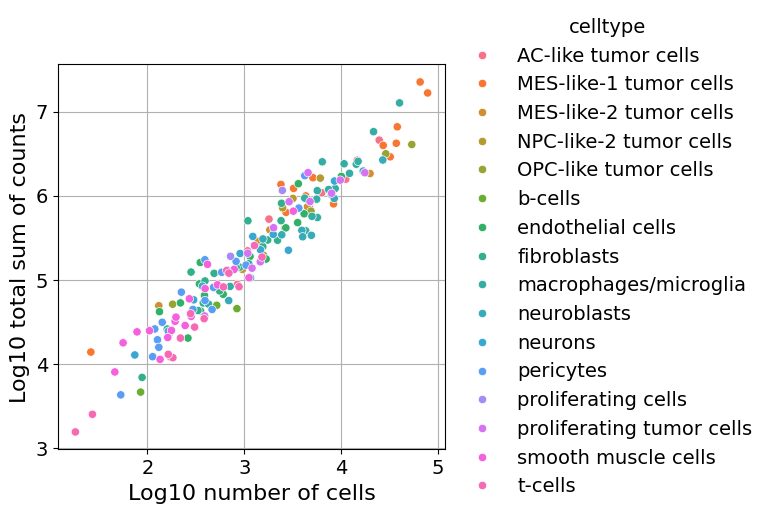

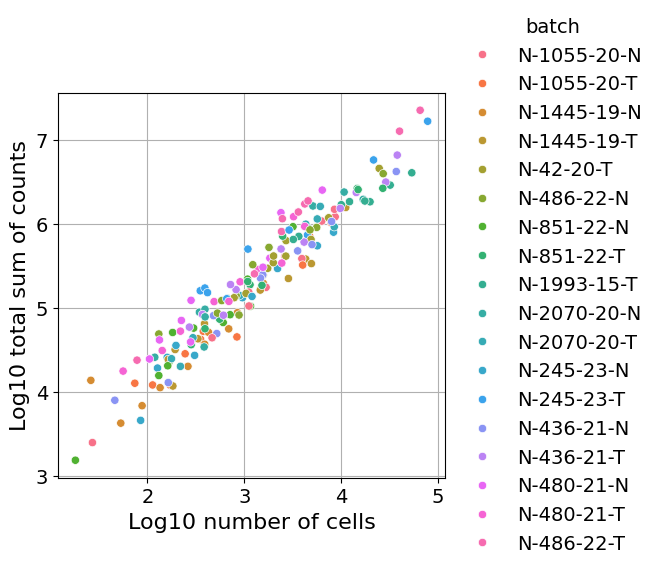

In [44]:
plot_psbulk_samples(psbulk, groupby='celltype')
plot_psbulk_samples(psbulk, groupby='batch')

In [45]:
psbulk.X

array([[3.4093e+04, 4.1368e+04, 2.9776e+04, ..., 5.7000e+01, 2.2000e+01,
        7.0000e+00],
       [2.9618e+04, 3.9618e+04, 8.2488e+04, ..., 5.0000e+01, 1.0000e+01,
        5.0000e+00],
       [3.3200e+03, 1.7150e+03, 4.7590e+03, ..., 1.3000e+01, 3.0000e+00,
        2.0000e+00],
       ...,
       [1.8239e+04, 1.0785e+04, 1.1052e+04, ..., 3.0000e+00, 2.0000e+00,
        0.0000e+00],
       [8.0000e+00, 1.0000e+00, 2.0000e+00, ..., 0.0000e+00, 7.0000e+00,
        3.0000e+00],
       [2.2890e+03, 1.7806e+04, 5.9000e+03, ..., 1.4000e+01, 1.8000e+01,
        1.4000e+01]], dtype=float32)

In [46]:
# Store raw counts in layers
psbulk.layers['counts'] = psbulk.X.copy()

# Normalize, scale and compute pca
sc.pp.normalize_total(psbulk, target_sum=100)
sc.pp.log1p(psbulk)
#sc.pp.scale(pdata, max_value=10)
sc.tl.pca(psbulk)

In [47]:
psbulk.X

array([[1.4195606e+00, 1.5695187e+00, 1.3186303e+00, ..., 5.2282135e-03,
        2.0211474e-03, 6.4353558e-04],
       [1.6412981e+00, 1.8820642e+00, 2.5329869e+00, ..., 7.0013390e-03,
        1.4041947e-03, 7.0234388e-04],
       [1.5584776e+00, 1.0777088e+00, 1.8527987e+00, ..., 1.4583077e-02,
        3.3842507e-03, 2.2574391e-03],
       ...,
       [2.0936005e+00, 1.6499391e+00, 1.6697435e+00, ..., 1.1694586e-03,
        7.7979092e-04, 0.0000000e+00],
       [4.1462874e-01, 6.2247846e-02, 1.2084692e-01, ..., 0.0000000e+00,
        3.7127560e-01, 1.7620139e-01],
       [7.9949522e-01, 2.3537226e+00, 1.4245510e+00, ..., 7.4608917e-03,
        9.5823901e-03, 7.4608917e-03]], dtype=float32)

In [48]:
psbulk.layers['counts']

array([[3.4093e+04, 4.1368e+04, 2.9776e+04, ..., 5.7000e+01, 2.2000e+01,
        7.0000e+00],
       [2.9618e+04, 3.9618e+04, 8.2488e+04, ..., 5.0000e+01, 1.0000e+01,
        5.0000e+00],
       [3.3200e+03, 1.7150e+03, 4.7590e+03, ..., 1.3000e+01, 3.0000e+00,
        2.0000e+00],
       ...,
       [1.8239e+04, 1.0785e+04, 1.1052e+04, ..., 3.0000e+00, 2.0000e+00,
        0.0000e+00],
       [8.0000e+00, 1.0000e+00, 2.0000e+00, ..., 0.0000e+00, 7.0000e+00,
        3.0000e+00],
       [2.2890e+03, 1.7806e+04, 5.9000e+03, ..., 1.4000e+01, 1.8000e+01,
        1.4000e+01]], dtype=float32)

In [49]:
swap_layer(psbulk, 'counts', X_layer_key="counts_log1p", inplace=True) # Return raw counts to X

In [50]:
psbulk.X,psbulk.layers['counts'],psbulk.layers['counts_log1p']

(array([[3.4093e+04, 4.1368e+04, 2.9776e+04, ..., 5.7000e+01, 2.2000e+01,
         7.0000e+00],
        [2.9618e+04, 3.9618e+04, 8.2488e+04, ..., 5.0000e+01, 1.0000e+01,
         5.0000e+00],
        [3.3200e+03, 1.7150e+03, 4.7590e+03, ..., 1.3000e+01, 3.0000e+00,
         2.0000e+00],
        ...,
        [1.8239e+04, 1.0785e+04, 1.1052e+04, ..., 3.0000e+00, 2.0000e+00,
         0.0000e+00],
        [8.0000e+00, 1.0000e+00, 2.0000e+00, ..., 0.0000e+00, 7.0000e+00,
         3.0000e+00],
        [2.2890e+03, 1.7806e+04, 5.9000e+03, ..., 1.4000e+01, 1.8000e+01,
         1.4000e+01]], dtype=float32),
 array([[3.4093e+04, 4.1368e+04, 2.9776e+04, ..., 5.7000e+01, 2.2000e+01,
         7.0000e+00],
        [2.9618e+04, 3.9618e+04, 8.2488e+04, ..., 5.0000e+01, 1.0000e+01,
         5.0000e+00],
        [3.3200e+03, 1.7150e+03, 4.7590e+03, ..., 1.3000e+01, 3.0000e+00,
         2.0000e+00],
        ...,
        [1.8239e+04, 1.0785e+04, 1.1052e+04, ..., 3.0000e+00, 2.0000e+00,
         0.0000e+00

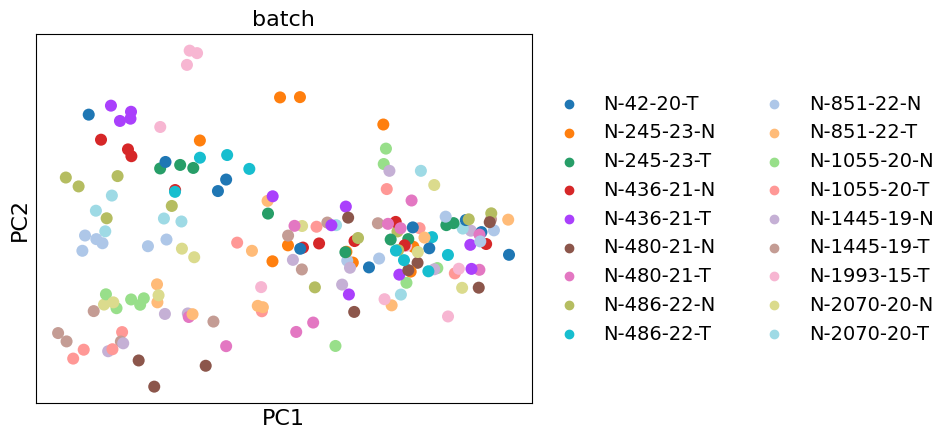

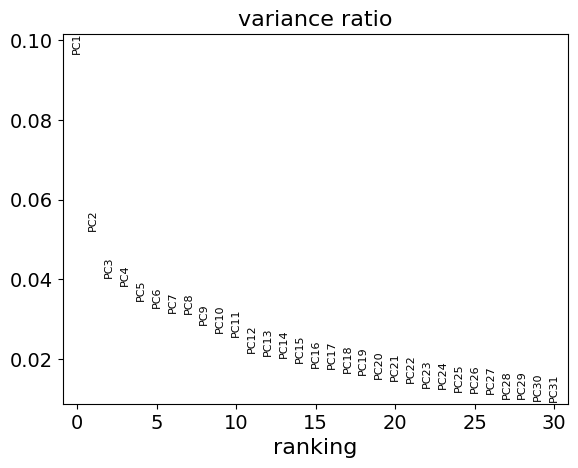

In [51]:
sc.pl.pca(psbulk, color=['batch'], ncols=1, size=300)
sc.pl.pca_variance_ratio(psbulk)

In [52]:
def check_if_statsmodels():
    try:
        import statsmodels.api as sm
        from statsmodels.formula.api import ols
        from statsmodels.stats.multitest import multipletests
        return sm, ols, multipletests
    except Exception:
        raise ImportError('statsmodels is not installed. Please install it.')


def format_assoc_results(data, stats_df, inplace, obsm_key, uns_key, use_X, layer):
    if isinstance(data, list):
        return stats_df
    elif inplace:
        # which of obsm_key, use_X, or layer is not None?
        if obsm_key is not None:
            key = obsm_key.replace('X_', '') + '_anova' if uns_key is None else uns_key
        elif use_X:
            key = 'X_anova' if uns_key is None else uns_key
        elif layer is not None:
            key = layer + '_anova' if uns_key is None else uns_key
        if not hasattr(data, 'uns'):
            data.uns = {key: stats_df}
        else:
            data.uns[key] = stats_df
    else:
        return stats_df

In [53]:
def _check_anova_inputs(data, obs_keys=None, obsm_key=None, use_X=False, layer=None):

    # check that data is not None
    assert data is not None, 'data cannot be None'

    # check whether data is a list, of size 2
    if isinstance(data, list):
        assert len(data) == 2, 'data must be a list of size 2'
        # both elements in data must be pd.Dataframe instances
        assert isinstance(data[0], pd.DataFrame), 'data[0] must be a pd.DataFrame instance'
        assert isinstance(data[1], pd.DataFrame), 'data[1] must be a pd.DataFrame instance'
        # both data[0] and data[1] must have the same index
        assert data[0].index.equals(data[1].index), 'data[0] and data[1] must have the same index'

        dependent_variables = data[0].columns
        explanatory_variables = data[1].columns
        scores = data[0]
        obs = data[1]

    elif hasattr(data, 'obs'):
        assert isinstance(data.obs, pd.DataFrame), 'data.obs must be a pd.DataFrame instance'
        obs = data.obs
        if obsm_key is None and not use_X and layer is None:
            raise ValueError('When providing an AnnData or MuData object, either obsm_key, use_X or layer must be specified')
        elif (obsm_key is not None and use_X) or (obsm_key is not None and layer is not None) or (use_X and layer is not None):
            raise ValueError('When providing an AnnData or MuData object, only one of obsm_key, \
                             use_X or layer must be specified')
        elif obsm_key is not None:
            assert hasattr(data, 'obsm'), 'data must have an .obsm attribute'
            assert obsm_key in data.obsm.keys(), 'obsm_key must be a key in data.obsm'
            column_name = obsm_key.replace('X_', '').replace('pca', 'PC').replace('mofa', 'Factor').replace('umap', 'UMAP')
            scores = pd.DataFrame(data.obsm[obsm_key], index=data.obs.index,
                                  columns=['{0}{1}'.format(column_name, 1 + x) for x in range(data.obsm[obsm_key].shape[1])])
        elif use_X:
            assert hasattr(data, 'X'), 'data must have a .X attribute'
            scores = pd.DataFrame(data.X, index=data.obs.index, columns=data.var.index)
        elif layer is not None:
            assert hasattr(data, 'layers'), 'data must have a .layers attribute'
            assert layer in data.layers.keys(), 'layer must be a key in data.layers'
            scores = pd.DataFrame(data.layers[layer], index=data.obs.index, columns=data.var.index)

        assert scores.index.equals(obs.index), 'scores and obs must have the same index'
        dependent_variables = scores.columns
        explanatory_variables = obs.columns
    else:
        raise TypeError('data must be a list of size 2 or an AnnData or MuData object with .obs dataframe')

    # select only the columns in obs_keys
    if obs_keys is None:
        obs_keys = explanatory_variables
    assert all([var in explanatory_variables for var in obs_keys]), 'obs_keys must be a subset of the obs columns'
    obs = obs.filter(obs_keys, axis=1)
    explanatory_variables = obs_keys

    # check that there are no . in the dependent and explanatory variables
    assert all(['.' not in var for var in dependent_variables]), 'column names of dependent variables cannot contain .'
    assert all(['.' not in var for var in explanatory_variables]), 'column names of explanatory variables \
    (obs) cannot contain .'
    # check there is no overlap of column names between dependent and explanatory variables
    assert len([value for value in dependent_variables if value in explanatory_variables]) == 0, 'dependent and explanatory \
    variables cannot have the same column names'

    # merge scores and obs
    scores = pd.merge(scores, obs, left_index=True, right_index=True)

    return scores, list(dependent_variables), list(explanatory_variables)


In [54]:
def get_metadata_associations(data, obs_keys=None, obsm_key=None, use_X=False, layer=None, uns_key=None, inplace=False,
                              alpha=0.05, method='fdr_bh', verbose=False):
    """
    Associate the data to sample metadata using ANOVA. The data can be any kind of embedding stored in a layer,
    obsm or X matrix.

    Requires statsmodels to be installed.

    Parameters
    ----------
    data : list, AnnData or MuData
        The input data for ANOVA testing. It can be either a list of two pandas DataFrames [data, obs],
        an AnnData or MuData object.
    obs_keys: list, optional
        Column names of obs (sample metadata) which should be tested. If not provided, all columns in obs will be used.
    obsm_key : str, optional
        A key specifying where in obsm the data is located when providing an AnnData/MuData object. Either
        ``obsm_key``, ``use_X``, or ``layer`` must be specified.
    use_X : bool, optional
        A boolean flag indicating whether to use the data in ``.X`` from the AnnData/MuData object when providing
        the ``data``. Either ``obsm_key``, ``use_X``, or ``layer`` must be specified.
    layer : str, optional
        Which layer to use when providing an AnnData/MuData object. Either ``obsm_key``,
        ``use_X``, or ``layer`` must be specified.
    uns_key : str, optional
        Where results will be stored the AnnData/MuData object.
    inplace : bool, optional
        Whether to store the results in the AnnData or MuData object. If ``False``, the function returns a pandas
        DataFrame with the results.
    alpha : float, optional
        The significance level for multiple testing correction (default is 0.05).
    method : (str, optional):
        The method used for multiple testing correction. It can be one of the methods supported by
        ``statsmodels.stats.multitest.multipletests`` (default is ``fdr_bh``, i.e., Benjamini-Hochberg method).
    verbose : bool
        Whether to show progress.

    Returns
    -------
    results: pd.DataFrame
        DataFrame with ANOVA results. If ``data`` is an AnnData or MuData object and ``inplace`` is ``True``,
        the results are stored in ``data.uns[uns_key]``.
    """

    sm, ols, multipletests = check_if_statsmodels()

    scores, dependent_variables, explanatory_variables = _check_anova_inputs(
        data,
        obs_keys=obs_keys,
        obsm_key=obsm_key,
        use_X=use_X,
        layer=layer
    )

    # for each dependent variable, test the association with the other columns in scores using an ANOVA
    # collect p-values and eta_sq in a dataframe
    for dependent in tqdm(dependent_variables, disable=not verbose):
        stats = []
        for explainer in explanatory_variables:
            # check the data type of the column
            if scores[explainer].dtype == 'object' or scores[explainer].dtype == 'category':
                # if it is a string, the explanatory variable is a categorical variable
                var_name = 'C({0})'.format(explainer)
            # if it is a float or integer, the explanatory variable is a continuous variable
            elif scores[explainer].dtype == 'float' or scores[explainer].dtype == 'int':
                var_name = '{0}'.format(explainer)
            # else raise an error
            else:
                raise ValueError('Column {0} has an unknown data type. Make sure it is either \
                categorical/object or float/int'.format(explainer))

            # create the formula
            formula = '{0} ~ {1}'.format(dependent, var_name)

            # fit the model
            mod = ols(formula, data=scores.filter([dependent, explainer], axis=1)).fit()
            # get the ANOVA table
            try:
                aov_table = sm.stats.anova_lm(mod, typ=2)
            except ValueError:
                print('WARNING: could not compute ANOVA for {0} and {1}'.format(dependent, explainer))
                row = [explainer, np.nan, np.nan]
            else:
                # compute eta squared from anova table
                eta_sq = aov_table.loc[var_name, 'sum_sq'] / aov_table.sum(axis=0)['sum_sq']
                # eta squared = SS from explanatory variable / SStotal (i.e. sum of all SS from variables plus residual SS)
                row = [explainer, aov_table.iloc[0]['PR(>F)'], eta_sq]
            stats.append(row)

        stats = pd.DataFrame(stats, columns=['variable', 'pval', 'eta_sq']).set_index('variable')
        stats['factor'] = dependent
        # Add p-val correction
        stats['p_adj'] = multipletests(stats['pval'], alpha=alpha, method=method)[1]
        if dependent_variables.index(dependent) == 0:
            stats_df = stats.copy()
        else:
            stats_df = pd.concat([stats_df, stats], axis=0, join='outer', sort=False)

    stats_df = stats_df.reset_index()

    return format_assoc_results(data, stats_df, inplace, obsm_key, uns_key, use_X, layer)


In [55]:
get_metadata_associations(
    psbulk,
    obs_keys = ['sample_type','tumor_area','patient_id','celltype', 'psbulk_n_cells', 'psbulk_counts'],  # Metadata columns to associate to PCs
    obsm_key='X_pca',  # Where the PCs are stored
    uns_key='pca',  # Where the results are stored
    inplace=True,
)

In [56]:
def _check_assoc_plot_intputs(data, associations, cols, uns_key, obsm_key, use_X, layer, stat_col):
    # check that the data is a panda frame or has an .uns attribute
    msg = 'data sould be an AnnData/MuData object with an .uns, and .obsm, .X, or .layers attribute'
    assert hasattr(data, 'uns') and (hasattr(data, 'obsm') or hasattr(data, 'X') or hasattr(data, 'layers')), msg
    assert uns_key is not None, 'uns_key must be specified'
    assert uns_key in data.uns.keys(), 'uns_key not found in data.uns'

    stats = data.uns[uns_key]
    assert stat_col in stats.columns, 'stat_col must be one of the columns in the anova results'

    if associations is not None:
        stats = stats[stats.variable.isin(associations)]
    if cols is not None:
        stats = stats[stats.factor.isin(cols)]

    # specify at least but only one of obsm_key, use_X, or layer
    assert obsm_key is not None or use_X is True or layer is not None, 'one of obsm_key, use_X, or layer must be specified'
    if (obsm_key is not None and use_X) or (obsm_key is not None and layer is not None) or (use_X and layer is not None):
        raise ValueError('only one of obsm_key, use_X, or layer should be specified')

    # get activities for main clusterplot
    if obsm_key is not None:
        assert hasattr(data, 'obsm'), 'the data does not have an .obsm attribute'
        assert obsm_key in data.obsm.keys(), 'obsm_key not found in data.obsm'
        if isinstance(data.obsm[obsm_key], pd.DataFrame):
            acts = data.obsm[obsm_key]
        else:
            column_name = obsm_key.replace('X_', '').replace('pca', 'PC').replace('mofa', 'Factor').replace('umap', 'UMAP')
            columns = ['{0}{1}'.format(column_name, 1 + x) for x in range(data.obsm[obsm_key].shape[1])]
            acts = pd.DataFrame(data.obsm[obsm_key],
                                index=data.obs.index,
                                columns=columns)
    elif layer is not None:
        assert hasattr(data, 'layers'), 'the data does not have a .layers attribute'
        assert layer in data.layers.keys(), 'layer not found in data.layers'
        acts = pd.DataFrame(data.layers[layer], index=data.obs.index, columns=data.var.index)
    elif use_X:
        assert hasattr(data, 'X'), 'the data does not have a .X attribute'
        acts = pd.DataFrame(data.X, index=data.obs.index, columns=data.var.index)


In [57]:
def get_filterbyexpr_inputs(adata, obs):
    # Extract inputs
    if type(adata) is AnnData:
        y, obs, var_names = adata.X, adata.obs, adata.var_names.values.astype('U')
    elif type(adata) is pd.DataFrame:
        y, var_names = adata.values, adata.columns.values.astype('U')
        if obs is None:
            obs = pd.DataFrame(index=adata.index)
    else:
        raise ValueError("""adata must be either an AnnData object or a df.""")
    return y, obs, var_names

In [58]:
def get_min_sample_size(group, obs, large_n, min_prop):
    # Minimum effect sample sample size for any of the coefficients
    if group is None:
        min_sample_size = obs.shape[0]
    elif isinstance(group, (str, list, np.ndarray, pd.Series)):
        if isinstance(group, str):
            group = obs[group].values
        elif isinstance(group, pd.Series):
            group = obs.values
        else:
            group = np.array(group)
        _, n = np.unique(group, return_counts=True)
        min_sample_size = np.min(n[n > 0])
    else:
        raise ValueError('group needs to be a column name, or a list/series/array of values.')

    if min_sample_size > large_n:
        min_sample_size = large_n + (min_sample_size - large_n) * min_prop

    return min_sample_size

In [59]:
def get_cpm_cutoff(lib_size, min_count):
    median_lib_size = np.median(lib_size)
    cpm_cutoff = min_count / median_lib_size * 1e6
    return cpm_cutoff

In [60]:
def get_cpm(y, lib_size):
    if type(lib_size) is float or type(lib_size) is int:
        return y / lib_size * 1e6
    else:
        return y / lib_size.reshape(-1, 1) * 1e6

In [61]:
def plot_filter_by_expr(adata, obs=None, group=None, lib_size=None, min_count=10, min_total_count=15, large_n=10,
                        min_prop=0.7, cmap='viridis', figsize=(5, 4), dpi=100, ax=None, return_fig=False, save=None, **kwargs):
    """
    Plot to help determining the thresholds of the ``decoupler.filter_by_expr`` function.

    Parameters
    ----------
    adata : AnnData
        AnnData obtained after running ``decoupler.get_pseudobulk``.
    obs : DataFrame, None
        If provided, metadata dataframe, only needed if ``adata`` is not an ``AnnData``.
    group : str, None
        Name of the ``.obs`` column to group by. If None, it assumes that all samples belong to one group.
    lib_size : int, float, None
        Library size. If None, default to the sum of reads per sample.
    min_count : int
        Minimum count requiered per gene for at least some samples.
    min_total_count : int
        Minimum total count required per gene across all samples.
    large_n : int
        Number of samples per group that is considered to be "large".
    min_prop : float
        Minimum proportion of samples in the smallest group that express the gene.
    cmap : str
        Colormap to use.
    figsize : tuple
        Figure size.
    dpi : int
        DPI resolution of figure.
    ax : Axes, None
        A matplotlib axes object. If None returns new figure.
    return_fig : bool
        Whether to return a Figure object or not.
    save : str, None
        Path to where to save the plot. Infer the filetype if ending on {``.pdf``, ``.png``, ``.svg``}.
    kwargs : dict
        Other keyword arguments are passed through to ``sns.histplot``.

    Returns
    -------
    fig : Figure, None
        If return_fig, returns Figure object.
    """

    # Extract inputs
    y, obs, var_names = get_filterbyexpr_inputs(adata, obs)

    # Compute lib_size if needed
    if lib_size is None:
        lib_size = np.sum(y, axis=1)

    # Minimum sample size cutoff
    min_sample_size = get_min_sample_size(group, obs, large_n, min_prop)
    min_sample_size -= 1e-14

    # Total count cutoff
    min_total_count -= 1e-14

    # CPM cutoff
    cpm_cutoff = get_cpm_cutoff(lib_size, min_count)

    # CPM thr
    cpm = get_cpm(y, lib_size)
    sample_size = np.sum(cpm >= cpm_cutoff, axis=0)

    # Total counts
    total_counts = np.sum(y, axis=0)
    total_counts[total_counts < 1.] = np.nan  # Handle 0s

    # Plot
    fig = None
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
    sns.histplot(x=np.log10(total_counts), y=sample_size, cmap=cmap, cbar=True,
                 cbar_kws=dict(shrink=.75, label='Number of features'),
                 discrete=(False, True), ax=ax, **kwargs)
    ax.axhline(y=min_sample_size - 0.5, c='gray', ls='--')
    ax.axvline(x=np.log10(min_total_count), c='gray', ls='--')
    ax.set_xlabel('Log10 total sum of counts')
    ax.set_ylabel('Number of samples')


    if return_fig:
        return fig

In [62]:
# filtering to specific cell type
psbulk=psbulk[psbulk.obs['celltype']=='endothelial cells']

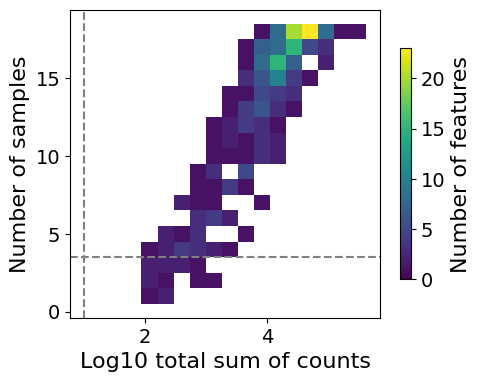

In [63]:
plot_filter_by_expr(psbulk, group='sample_type', min_count=15, min_total_count=10)

In [64]:
def filter_by_expr(adata, obs=None, group=None, lib_size=None, min_count=10, min_total_count=15, large_n=10, min_prop=0.7):
    """
    Determine which genes have sufficiently large counts to be retained in a statistical analysis.

    Adapted from the function ``filterByExpr`` of edgeR (https://rdrr.io/bioc/edgeR/man/filterByExpr.html).

    Parameters
    ----------
    adata : AnnData
        AnnData obtained after running ``decoupler.get_pseudobulk``.
    obs : DataFrame, None
        If provided, metadata dataframe, only needed if ``adata`` is not an ``AnnData``.
    group : str, None
        Name of the ``.obs`` column to group by. If None, it assumes that all samples belong to one group.
    lib_size : int, float, None
        Library size. If None, default to the sum of reads per sample.
    min_count : int
        Minimum count requiered per gene for at least some samples.
    min_total_count : int
        Minimum total count required per gene across all samples.
    large_n : int
        Number of samples per group that is considered to be "large".
    min_prop : float
        Minimum proportion of samples in the smallest group that express the gene.

    Returns
    -------
    genes : ndarray
        List of genes to be kept.
    """

    # Define limits
    min_count = np.clip(min_count, 0, None)
    min_total_count = np.clip(min_total_count, 0, None)
    large_n = np.clip(large_n, 0, None)
    min_prop = np.clip(min_prop, 0, 1)

    # Extract inputs
    y, obs, var_names = get_filterbyexpr_inputs(adata, obs)

    # Compute lib_size if needed
    if lib_size is None:
        lib_size = np.sum(y, axis=1)

    # Minimum sample size cutoff
    min_sample_size = get_min_sample_size(group, obs, large_n, min_prop)
    min_sample_size -= 1e-14

    # Total count cutoff
    min_total_count -= 1e-14

    # CPM cutoff
    cpm_cutoff = get_cpm_cutoff(lib_size, min_count)

    # CPM mask
    cpm = get_cpm(y, lib_size)
    sample_size = np.sum(cpm >= cpm_cutoff, axis=0)
    keep_cpm = sample_size >= min_sample_size

    # Total counts msk
    keep_total_count = np.sum(y, axis=0) >= min_total_count

    # Merge msks
    msk = keep_cpm & keep_total_count
    genes = var_names[msk]

    return genes

In [65]:
genes = filter_by_expr(psbulk, group='sample_type', min_count=15, min_total_count=10)

In [66]:
# Filter by these genes
psbulk =psbulk[:, genes].copy()
psbulk.obs

,batch,celltype,patient_id,sample_type,scale,tumor_area,psbulk_n_cells,psbulk_counts
N-1055-20-N_endothelial cells,N-1055-20-N,endothelial cells,1,relapse 1,1.0,infiltrationzone,1681.0,177106.0
N-1055-20-T_endothelial cells,N-1055-20-T,endothelial cells,1,relapse 1,1.0,tumor center,354.0,42674.0
N-1445-19-N_endothelial cells,N-1445-19-N,endothelial cells,3,relapse 1,1.0,infiltrationzone,262.0,20357.0
N-1445-19-T_endothelial cells,N-1445-19-T,endothelial cells,3,relapse 1,1.0,tumor center,388.0,65347.0
N-1993-15-T_endothelial cells,N-1993-15-T,endothelial cells,3,initial diagnosis,1.0,tumor center,10062.0,1701824.0
N-2070-20-N_endothelial cells,N-2070-20-N,endothelial cells,3,relapse 2,1.0,infiltrationzone,344.0,89726.0
N-2070-20-T_endothelial cells,N-2070-20-T,endothelial cells,3,relapse 2,1.0,tumor center,698.0,126214.0
N-245-23-N_endothelial cells,N-245-23-N,endothelial cells,2,relapse 1,1.0,infiltrationzone,160.0,26040.0
N-245-23-T_endothelial cells,N-245-23-T,endothelial cells,2,relapse 1,1.0,tumor center,351.0,161199.0
N-42-20-T_endothelial cells,N-42-20-T,endothelial cells,1,initial diagnosis,1.0,tumor center,2690.0,416292.0


In [67]:
psbulk.var

""
genes
A2ML1
ABCC9
ABCD4
ABO
ACKR1
...
TUB
VIPR2
XRCC3


In [68]:
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [69]:
# Build DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    adata=psbulk,
    design_factors='sample_type',
    ref_level=['sample_type', 'initial diagnosis'],
    refit_cooks=True,
    inference=inference,
)

/var/folders/jr/048kfmrx5ddghsh_1l82f7280000gp/T/ipykernel_48748/308484877.py:3: UserWarning: Same factor names in the design contain underscores ('_'). They will
                be converted to hyphens ('-').
  dds = DeseqDataSet(


In [70]:
# Compute LFCs
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.12 seconds.

Fitting dispersion trend curve...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.10 seconds.

Fitting LFCs...
... done in 0.10 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 57 outlier genes.

Fitting dispersions...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.05 seconds.

Fitting LFCs...
... done in 0.05 seconds.



In [71]:
# Extract contrast between  'relapse 1' vs 'initial diagnosis'
stat_res = DeseqStats(
    dds,
    contrast=['sample-type', 'relapse 1', 'initial diagnosis'],
    inference=inference,
)

In [72]:
# Compute Wald test
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: sample-type relapse 1 vs initial diagnosis
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
genes                                                                      
A2ML1   7312.144751       -1.067071  0.933602 -1.142961  0.253055  0.510043
ABCC9   1543.462346        0.178965  0.980890  0.182451  0.855229  0.931062
ABCD4   3930.677773        0.956149  0.808230  1.183016  0.236803  0.510043
ABO     2216.565858        0.923003  0.828770  1.113702  0.265407  0.510043
ACKR1   1202.781809        0.195203  0.577263  0.338153  0.735248  0.864307
...             ...             ...       ...       ...       ...       ...
TUB       26.769576        1.979422  1.553796  1.273926       NaN       NaN
VIPR2     22.651727        3.619479  1.220076  2.966600  0.003011  0.039145
XRCC3     13.049499        3.177467  1.119101  2.839303  0.004521  0.049960
XRCC5      9.441299       -0.716476  1.246067 -0.574990       NaN       NaN
ZNF860 

... done in 0.09 seconds.



In [73]:
# Extract results
results_df = stat_res.results_df
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
genes,,,,,,
A2ML1,7312.144751,-1.067071,0.933602,-1.142961,0.253055,0.510043
ABCC9,1543.462346,0.178965,0.980890,0.182451,0.855229,0.931062
ABCD4,3930.677773,0.956149,0.808230,1.183016,0.236803,0.510043
ABO,2216.565858,0.923003,0.828770,1.113702,0.265407,0.510043
ACKR1,1202.781809,0.195203,0.577263,0.338153,0.735248,0.864307
...,...,...,...,...,...,...
TUB,26.769576,1.979422,1.553796,1.273926,NaN,NaN
VIPR2,22.651727,3.619479,1.220076,2.966600,0.003011,0.039145
XRCC3,13.049499,3.177467,1.119101,2.839303,0.004521,0.049960


In [74]:
results_df.rename(columns={'pvalue': 'pvals'}, inplace=True)
results_df.index.name = 'gene'
results_df.reset_index(inplace=True)

results_df['neg_log10_pvals'] = -np.log10(results_df['pvals'])


In [75]:
results_df

,gene,baseMean,log2FoldChange,lfcSE,stat,pvals,padj,neg_log10_pvals
0,A2ML1,7312.144751,-1.067071,0.933602,-1.142961,0.253055,0.510043,0.596785
1,ABCC9,1543.462346,0.178965,0.980890,0.182451,0.855229,0.931062,0.067918
2,ABCD4,3930.677773,0.956149,0.808230,1.183016,0.236803,0.510043,0.625613
3,ABO,2216.565858,0.923003,0.828770,1.113702,0.265407,0.510043,0.576088
4,ACKR1,1202.781809,0.195203,0.577263,0.338153,0.735248,0.864307,0.133566
...,...,...,...,...,...,...,...,...
260,TUB,26.769576,1.979422,1.553796,1.273926,NaN,NaN,NaN
261,VIPR2,22.651727,3.619479,1.220076,2.966600,0.003011,0.039145,2.521271
262,XRCC3,13.049499,3.177467,1.119101,2.839303,0.004521,0.049960,2.344744
263,XRCC5,9.441299,-0.716476,1.246067,-0.574990,NaN,NaN,NaN


In [76]:
from insitupy.plotting import volcano_plot

In [77]:
from insitupy import differential_gene_expression

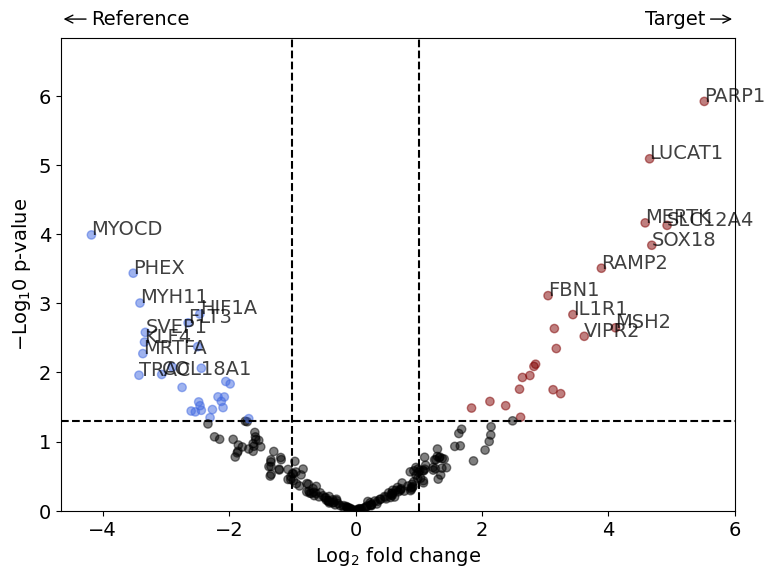

In [79]:
volcano_plot(data=results_df,logfoldchanges_column='log2FoldChange',pval_column='neg_log10_pvals',significance_threshold = 0.05,fold_change_threshold= 1, title = None,
                 adjust_labels= False,
                 savepath = None,
                 save_only=False,
                 dpi_save= 300,
                 label_top_n= 10,
                 figsize = (8, 6),
                 config_table=None,
                 scores=None,
                 )